# Finding How The Data Is Distributed

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

## Goal

Practise checking how values are distributed in the dataset using missing-value checks, counts, visualisations, language comparisons, correlation, and crosstab analysis.


## Install required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## Step 1: Import libraries and load data

This step imports the main libraries and loads the survey dataset.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Step 2: Examine the structure of the data

This step checks column names, data types, and general dataframe information.


In [3]:
# Display column names
print(df.columns)

# Display data types of each column
print(df.dtypes)

# Display summary information about the dataset
df.info()


Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


## Step 3: Handle missing data

This step checks missing values, creates a dropped-missing copy, and fills selected missing values in `df`.

Important: `df_cleaned` is created, but the later analysis continues mainly with `df`.


In [4]:
# Check for missing values in each column
print(df.isnull().sum())

# Option 1: Drop rows with any missing values
# This creates a separate dataframe, but the later analysis mainly continues with df.
df_cleaned = df.dropna()

# Option 2: Fill missing values with default labels
df['RemoteWork'] = df['RemoteWork'].fillna('Unknown')
df['JobSat'] = df['JobSat'].fillna('Not answered')


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64


## Step 4: Analyze key columns

This step counts responses in important columns to understand their distributions.


In [5]:
# Analyze Employment column
print(df['Employment'].value_counts())

# Analyze Job Satisfaction column
print(df['JobSat'].value_counts())

# Analyze Years of Professional Coding column
print(df['YearsCodePro'].value_counts())


Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

## Step 5: Visualize job satisfaction

This step removes `Not answered` values and visualises real `JobSat` scores with a KDE plot and a pie chart.


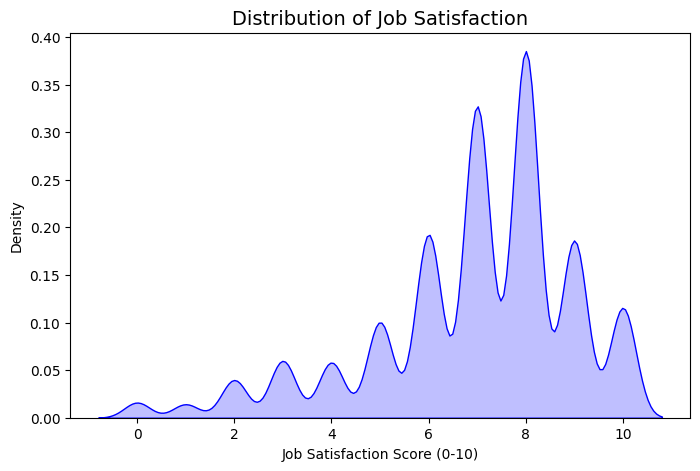

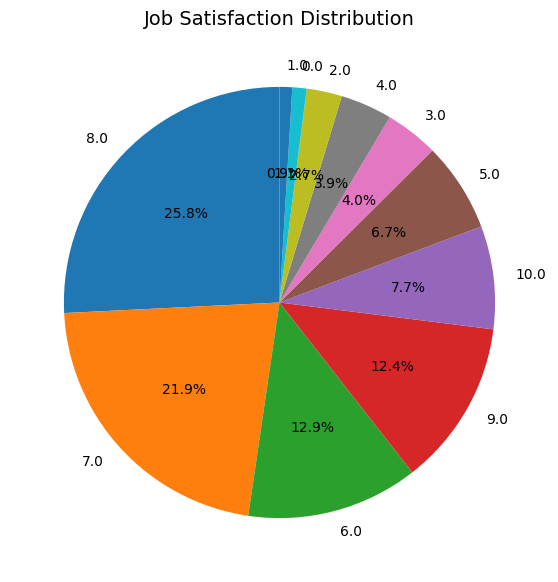

In [6]:
# Filter out 'Not answered'
job_sat = df[df['JobSat'] != 'Not answered']['JobSat'].astype(float)

# Create KDE plot
plt.figure(figsize=(8, 5))
sns.kdeplot(job_sat, fill=True, color='blue')
plt.title('Distribution of Job Satisfaction', fontsize=14)
plt.xlabel('Job Satisfaction Score (0-10)')
plt.ylabel('Density')
plt.show()

# Create Pie Chart
job_counts = df['JobSat'].value_counts().drop('Not answered')
plt.figure(figsize=(7, 7))
plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Job Satisfaction Distribution', fontsize=14)
plt.show()


## Step 6: Programming languages analysis

This step compares languages respondents have worked with and languages they want to work with.


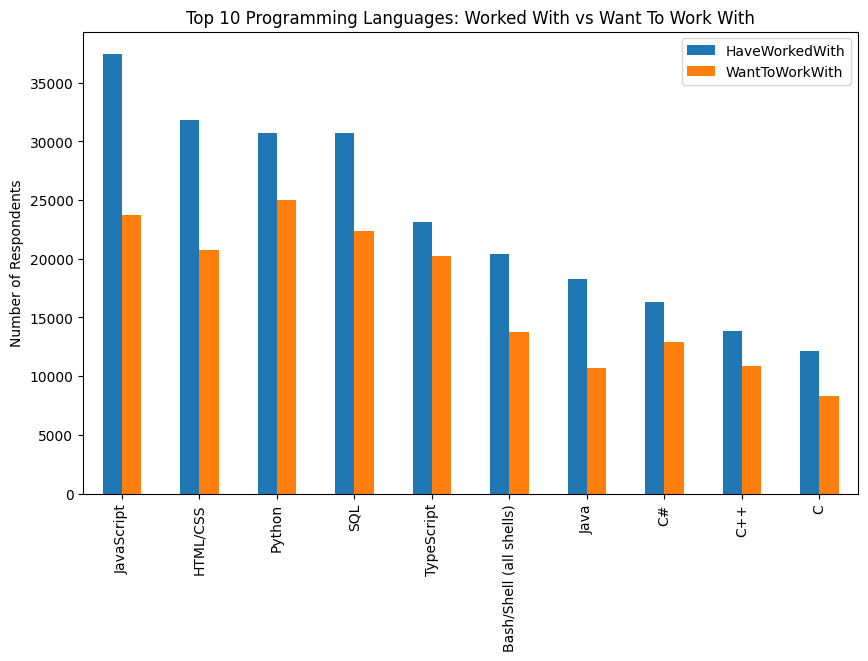

In [7]:
from collections import Counter

# Step 1: Split and count languages respondents have worked with
have_langs = df['LanguageHaveWorkedWith'].dropna().str.split(';').sum()
have_counts = Counter(have_langs)

# Step 2: Split and count languages respondents want to work with
want_langs = df['LanguageWantToWorkWith'].dropna().str.split(';').sum()
want_counts = Counter(want_langs)

# Step 3: Combine counts into a DataFrame
df_langs = pd.DataFrame({
    'HaveWorkedWith': pd.Series(have_counts),
    'WantToWorkWith': pd.Series(want_counts)
}).fillna(0)

# Step 4: Select top 10 based on usage
top_langs = df_langs.sort_values('HaveWorkedWith', ascending=False).head(10)

# Step 5: Plot grouped bar chart
top_langs.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Programming Languages: Worked With vs Want To Work With')
plt.ylabel('Number of Respondents')
plt.show()


## Step 7: Analyze remote work trends

This step visualises overall remote work distribution.

Important: the instruction mentions region, but this code shows overall RemoteWork distribution for all respondents.


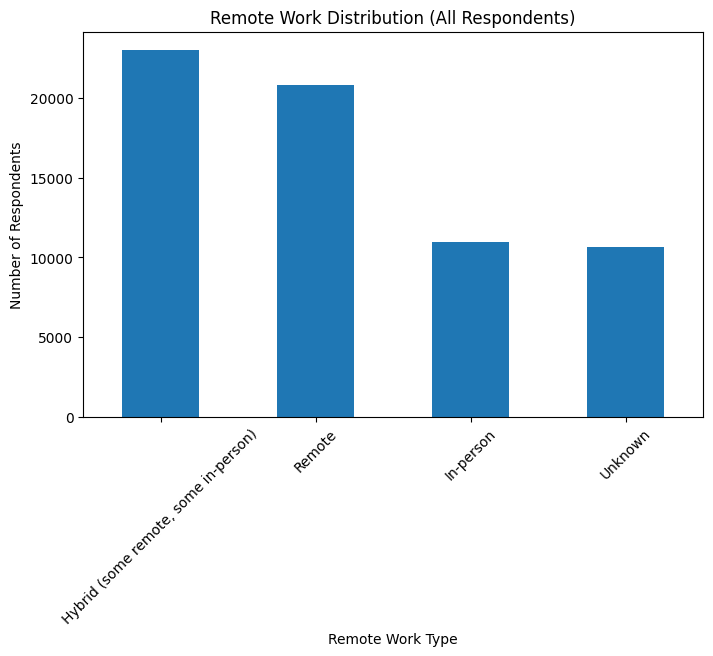

In [8]:
# Count RemoteWork categories
remote_counts = df['RemoteWork'].value_counts()

# Plot bar chart
remote_counts.plot(kind='bar', figsize=(8, 5))
plt.title('Remote Work Distribution (All Respondents)')
plt.ylabel('Number of Respondents')
plt.xlabel('Remote Work Type')
plt.xticks(rotation=45)
plt.show()


## Step 8: Correlation between job satisfaction and experience

This step converts `YearsCodePro` and `JobSat` into numeric values, then calculates Pearson correlation.

Important: this step changes `df` by removing rows where `JobSat` is `Not answered`.


In [9]:
# Step 1: Clean YearsCodePro
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Step 2: Clean JobSat
df = df[df['JobSat'] != 'Not answered']
df.loc[:, 'JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Step 3: Keep only relevant columns
df_corr = df[['JobSat', 'YearsCodePro']].dropna()

# Step 4: Pearson correlation
pearson_corr = df_corr['JobSat'].corr(df_corr['YearsCodePro'], method='pearson')

print('Pearson Correlation:', pearson_corr)


Pearson Correlation: 0.10415320964659903


## Step 9: Cross-tabulation analysis: Employment vs Education Level

This step compares education level and employment status with a crosstab table and stacked bar chart.

Important: because Step 8 changed `df`, this analysis uses the filtered version of `df`.


/tmp/ipykernel_47619/2026525224.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


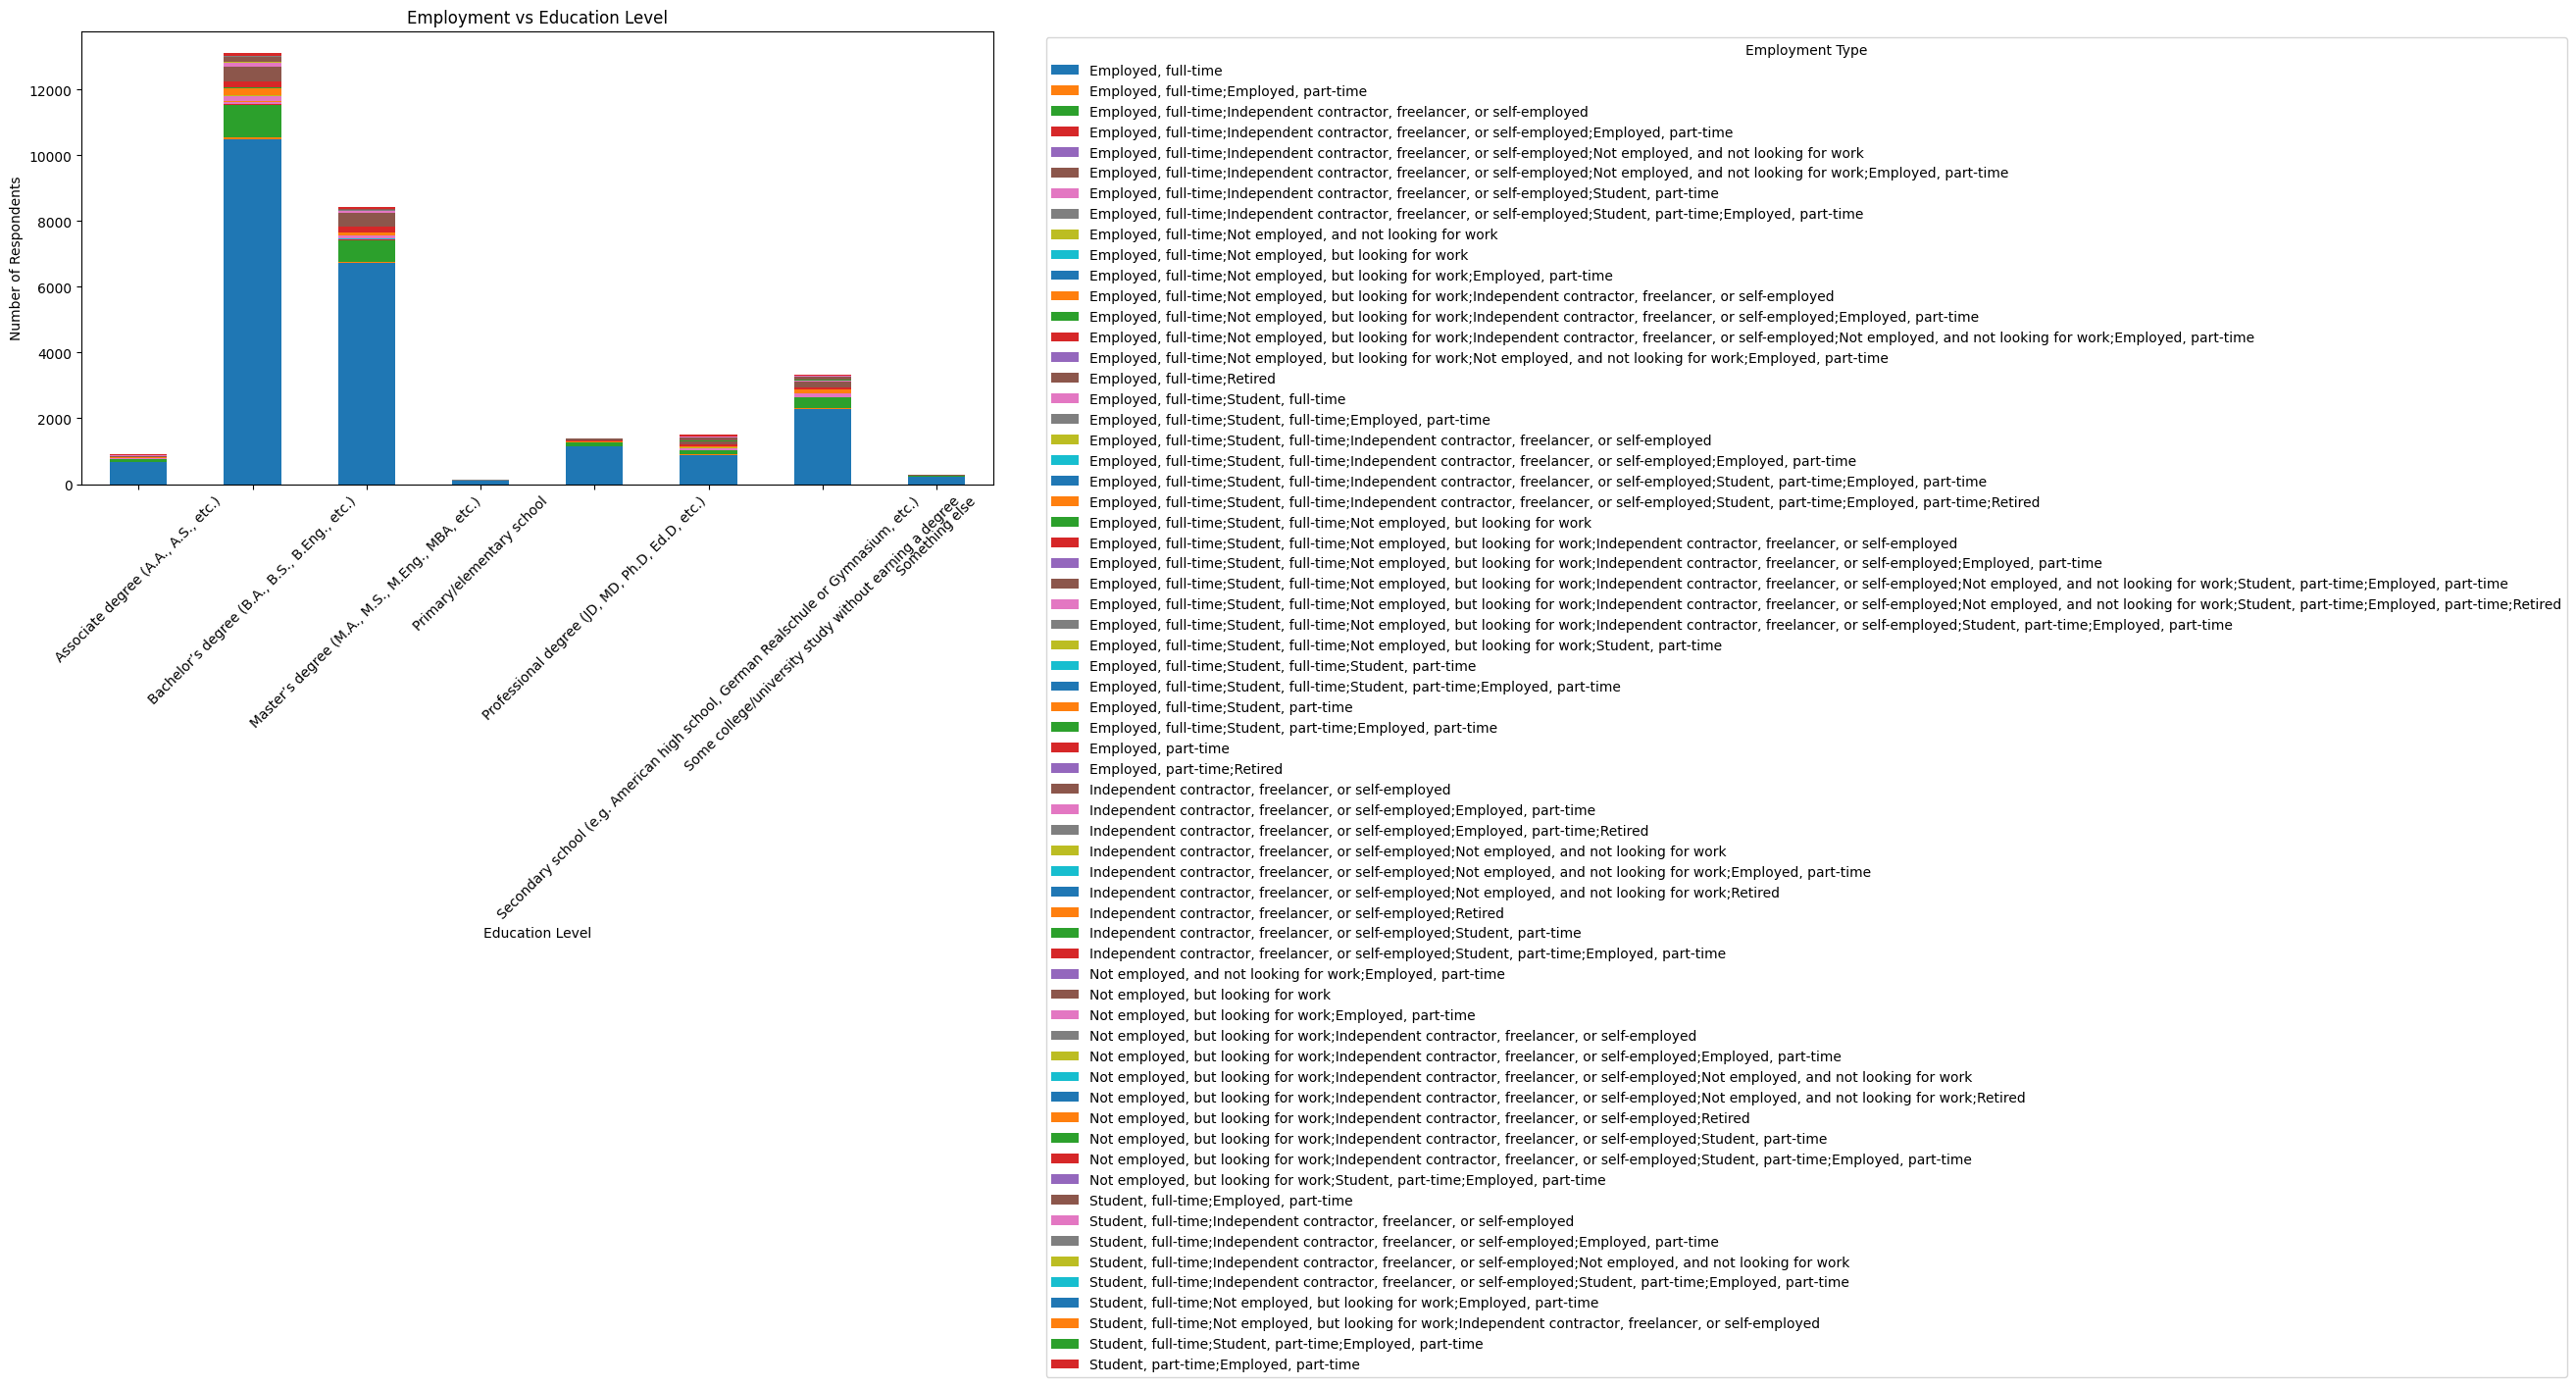

In [10]:
# Step 1: Create cross-tabulation
employment_edu = pd.crosstab(df['EdLevel'], df['Employment'])

# Step 2: Plot stacked bar chart
employment_edu.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Employment vs Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Step 10: Export cleaned data

This step exports the current version of `df` to a CSV file.

Important: this saves `df`, not `df_cleaned`. Since Step 8 filtered `df`, the exported file is the filtered version.


In [11]:
# Export cleaned dataset to CSV
df.to_csv('cleaned_survey_data.csv', index=False)
